## 3.7 Applied: #8, 9, and 13

### Problem 8

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize , poly)
from statsmodels.regression.linear_model import OLS
from statsmodels.sandbox.predict_functional import predict_functional
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
Auto = pd.read_csv('Auto.csv')
Auto['horsepower'] = pd.to_numeric(Auto['horsepower'], errors='coerce')
Auto['mpg']        = pd.to_numeric(Auto['mpg'], errors='coerce')
Auto = Auto.dropna()
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


### Codebook
| Column Name      | Description                           | Type                  | Notes                             |
| ---------------- | ------------------------------------- |-----------------------| --------------------------------- |
| **mpg**          | Miles per gallon                      | Continuous            | Fuel efficiency (higher = better) |
| **cylinders**    | Number of engine cylinders            | Discrete (Integer)    | Typical values: 3, 4, 5, 6, 8     |
| **displacement** | Engine displacement (cubic inches)    | Continuous            | Engine size                       |
| **horsepower**   | Engine horsepower                     | Continuous            | Power output                      |
| **weight**       | Vehicle weight (pounds)               | Continuous            | Heavier = usually lower MPG       |
| **acceleration** | Time to accelerate 0–60 mph (seconds) | Continuous            | Lower = faster                    |
| **year**         | Model year (70 = 1970, …, 82 = 1982)  | Discrete (Integer)    | Add 1900 for calendar year        |
| **origin**       | Country/region of origin              | Categorical (Encoded) | 1 = USA, 2 = Europe, 3 = Japan    |
| **name**         | Car model name                        | String                | Manufacturer + model              |



In [58]:
X = MS(['horsepower']).fit_transform(Auto)
y = Auto['mpg']
model = sm.OLS(y, X)
results = model.fit()
design = MS(['horsepower'])
X1 = design.fit_transform(Auto)
summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


i. there is a relationship between the predictor and the response

ii. for every one horsepower increase, the mpg goes down by .1578

iii. negative

In [62]:
df = pd.DataFrame({'horsepower':[98]})
X1 = design.transform(df)
X1


,intercept,horsepower
0,1.0,98


In [63]:
predictions = results.get_prediction(X1)
predictions.predicted_mean

array([24.46707715])

In [64]:
predictions.conf_int(alpha=.05)

array([[23.97307896, 24.96107534]])

/var/folders/lj/z4n5fz855bs_362sg07_kywr0000gn/T/ipykernel_10199/3732334231.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)


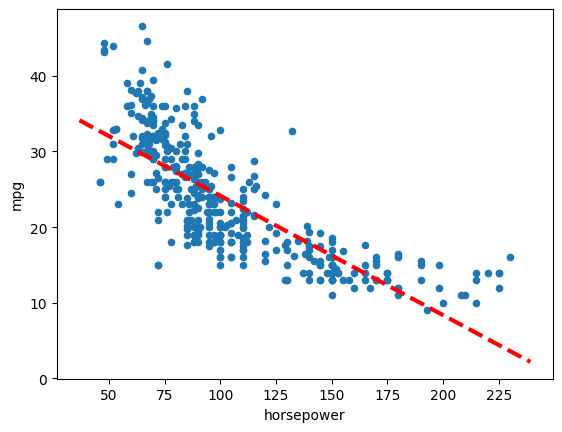

In [74]:
def abline(ax, b, m, *args, **kwargs):
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)
ax = Auto.plot.scatter('horsepower', 'mpg')
abline(ax, results.params[0], results.params[1], 'r--', linewidth=3)

### Problem 9

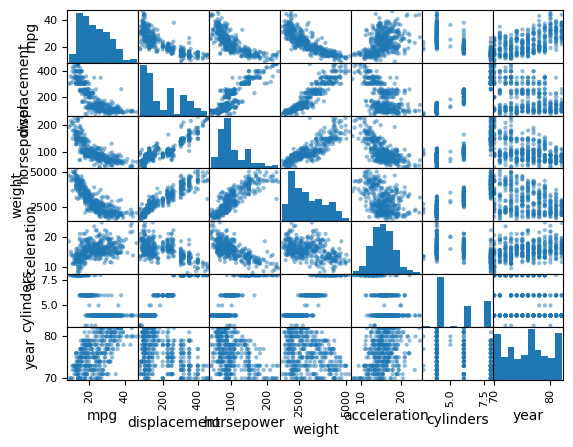

In [106]:
pd.plotting.scatter_matrix(Auto[['mpg','displacement','horsepower','weight','acceleration','cylinders','year']]);

In [107]:
df = Auto.drop(columns=['name'])
df.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [108]:
X = MS(Auto.drop(columns=['name','mpg'])).fit_transform(Auto)
y = Auto['mpg']
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [109]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# example: replace with your variables / dataframe
model = ols("y ~ displacement + horsepower + weight + acceleration + C(cylinders) + C(origin) + year", data=df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                   sum_sq     df           F        PR(>F)
C(cylinders)   566.487428    4.0   14.759101  3.219803e-11
C(origin)      243.976859    2.0   12.713006  4.525613e-06
displacement    64.367041    1.0    6.708002  9.967187e-03
horsepower      66.822446    1.0    6.963891  8.659252e-03
weight         804.046465    1.0   83.793585  3.431555e-18
acceleration     0.748227    1.0    0.077976  7.802106e-01
year          2177.348121    1.0  226.912016  1.543500e-40
Residual      3646.313230  380.0         NaN           NaN


the origin, year, acceleration, and amount of cylinders are significant variables to mpg due to their pr(>f) values being far below .05

Every year cars increase in fuel efficiency by about .75 mpg

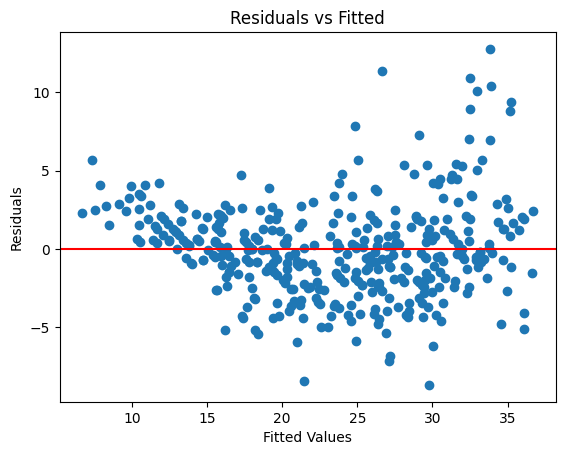

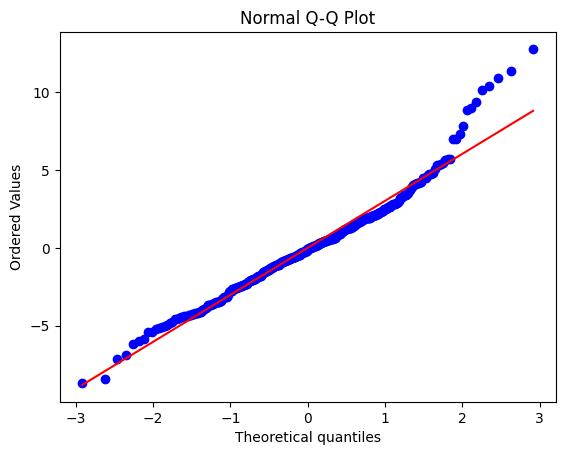

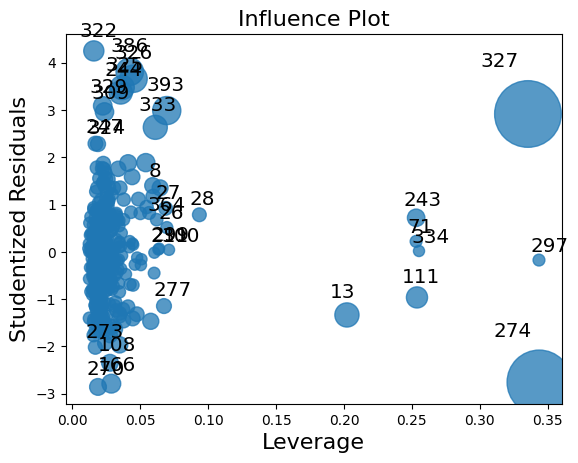

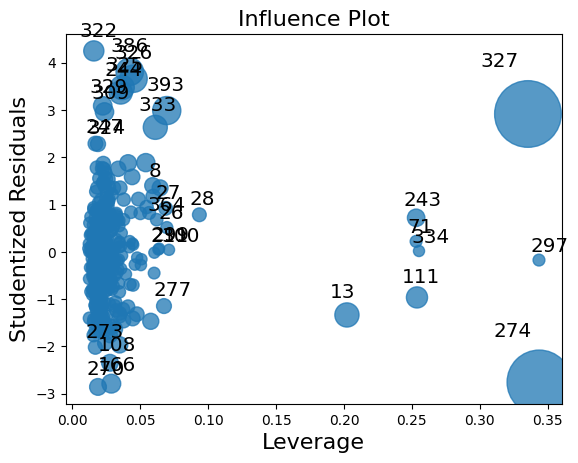

In [116]:
import scipy.stats as stats

residuals = model.resid
fitted = model.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

sm.graphics.influence_plot(model)
plt.show()

sm.graphics.influence_plot(model)
plt.show()

### Problem 13

In [149]:
rng = np.random.default_rng(42)
x = rng.normal(loc= 0, scale= 1, size=100)
eps = rng.normal(loc= 0, scale= np.sqrt(0.25), size=100)
y = -1 + 0.5*x + eps
df = pd.DataFrame({'x':x, 'y':y})
X = MS(['x']).fit_transform(df)
X

,intercept,x
0,1.0,0.304717
1,1.0,-1.039984
2,1.0,0.750451
3,1.0,0.940565
4,1.0,-1.951035
...,...,...
95,1.0,-1.447112
96,1.0,-1.322700
97,1.0,-0.997247
98,1.0,0.399774


In [135]:
model = sm.OLS(y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     77.87
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           4.29e-14
Time:                        13:34:45   Log-Likelihood:                -69.558
No. Observations:                 100   AIC:                             143.1
Df Residuals:                      98   BIC:                             148.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0023      0.049    -20.410      0.000      -1.100      -0.905
x              0.5596      0.063      8.824      0.000       0.434       0.685
==============================================================================
Omnibus:                        2.996   Durbin-Watson:                   1.682
Prob(Omnibus):                  0.224   Jarque-Bera (JB):                2.971
Skew:                           0.409   Prob(JB):                        0.226
Kurtosis:                       2.787   Cond. No.                         1.30
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [136]:
results.scale

np.float64(0.24014562104572276)

/var/folders/lj/z4n5fz855bs_362sg07_kywr0000gn/T/ipykernel_10199/3134509139.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, results.params[0], results.params[1], 'r--', linewidth=3, label='Fitted')


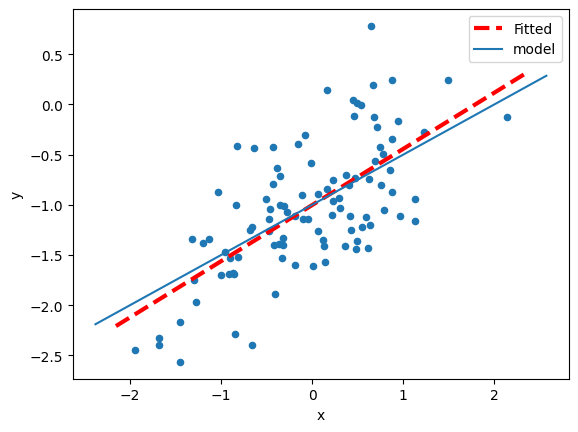

In [147]:
ax = df.plot.scatter(x='x', y='y')
abline(ax, results.params[0], results.params[1], 'r--', linewidth=3, label='Fitted')
abline(ax, -1, .5, label='model')
ax.legend()

In [148]:
X1 = MS([poly('x',degree=2)]).fit_transform(df)
model1 = sm.OLS(y,X1)
results1 = model1.fit()
results1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     40.62
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.53e-13
Time:                        13:46:43   Log-Likelihood:                -68.376
No. Observations:                 100   AIC:                             142.8
Df Residuals:                      97   BIC:                             150.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -1.0305      0.049    -21.169      0.000      -1.127      -0.934
poly(x, degree=2)[0]     4.3244      0.487      8.884      0.000       3.358       5.291
poly(x, degree=2)[1]    -0.7415      0.487     -1.523      0.131      -1.708       0.225
==============================================================================
Omnibus:                        2.591   Durbin-Watson:                   1.731
Prob(Omnibus):                  0.274   Jarque-Bera (JB):                2.542
Skew:                           0.380   Prob(JB):                        0.281
Kurtosis:                       2.818   Cond. No.                         10.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [150]:

epsless = rng.normal(loc= 0, scale= np.sqrt(0.05), size=100)
yless = -1 + 0.5*x + epsless
dfless = pd.DataFrame({'x':x, 'y':yless})
Xless = MS(['x']).fit_transform(dfless)
Xless

,intercept,x
0,1.0,0.304717
1,1.0,-1.039984
2,1.0,0.750451
3,1.0,0.940565
4,1.0,-1.951035
...,...,...
95,1.0,-1.447112
96,1.0,-1.322700
97,1.0,-0.997247
98,1.0,0.399774


In [153]:
modelless = sm.OLS(yless,Xless)
resultsless = modelless.fit()
resultsless.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     279.4
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.90e-30
Time:                        13:57:44   Log-Likelihood:                 5.9797
No. Observations:                 100   AIC:                            -7.959
Df Residuals:                      98   BIC:                            -2.749
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0140      0.023    -43.950      0.000      -1.060      -0.968
x              0.4980      0.030     16.714      0.000       0.439       0.557
==============================================================================
Omnibus:                        3.211   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.201   Jarque-Bera (JB):                2.554
Skew:                           0.345   Prob(JB):                        0.279
Kurtosis:                       3.371   Cond. No.                         1.30
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [154]:
resultsless.scale

np.float64(0.05301035742562592)

/var/folders/lj/z4n5fz855bs_362sg07_kywr0000gn/T/ipykernel_10199/1557121942.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, resultsless.params[0], resultsless.params[1], 'r--', linewidth=3, label='Fitted')


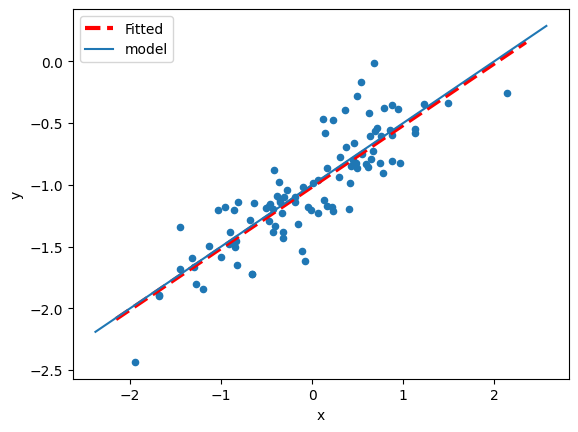

In [155]:
ax = dfless.plot.scatter(x='x', y='y')
abline(ax, resultsless.params[0], resultsless.params[1], 'r--', linewidth=3, label='Fitted')
abline(ax, -1, .5, label='model')
ax.legend()

In [156]:
epsmore = rng.normal(loc= 0, scale= np.sqrt(1), size=100)
ymore = -1 + 0.5*x + epsmore
dfmore = pd.DataFrame({'x':x, 'y':ymore})
Xmore = MS(['x']).fit_transform(dfmore)
Xmore

,intercept,x
0,1.0,0.304717
1,1.0,-1.039984
2,1.0,0.750451
3,1.0,0.940565
4,1.0,-1.951035
...,...,...
95,1.0,-1.447112
96,1.0,-1.322700
97,1.0,-0.997247
98,1.0,0.399774


In [157]:
modelmore = sm.OLS(ymore,Xmore)
resultsmore = modelmore.fit()
resultsmore.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     20.87
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.43e-05
Time:                        14:01:08   Log-Likelihood:                -142.38
No. Observations:                 100   AIC:                             288.8
Df Residuals:                      98   BIC:                             294.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.8925      0.102     -8.774      0.000      -1.094      -0.691
x              0.6001      0.131      4.568      0.000       0.339       0.861
==============================================================================
Omnibus:                        2.842   Durbin-Watson:                   1.902
Prob(Omnibus):                  0.241   Jarque-Bera (JB):                2.849
Skew:                          -0.381   Prob(JB):                        0.241
Kurtosis:                       2.679   Cond. No.                         1.30
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/var/folders/lj/z4n5fz855bs_362sg07_kywr0000gn/T/ipykernel_10199/1554439991.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, resultsmore.params[0], resultsmore.params[1], 'r--', linewidth=3, label='Fitted')


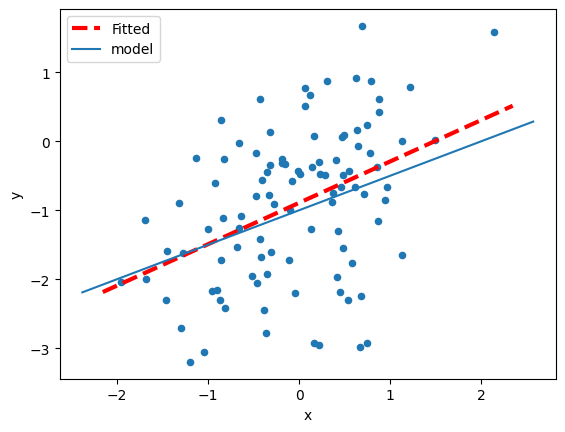

In [158]:
ax = dfmore.plot.scatter(x='x', y='y')
abline(ax, resultsmore.params[0], resultsmore.params[1], 'r--', linewidth=3, label='Fitted')
abline(ax, -1, .5, label='model')
ax.legend()